# Lab 4.3 - Inference with Different Quantization Methods

**Objective:** Load `Qwen/Qwen2.5-3B-Instruct` with multiple quantization methods and compare their VRAM usage, speed, and generation quality.

**Methods compared:**
1. **fp32 baseline** - full precision, no quantization
2. **bf16** - half precision (standard for modern GPU inference)
3. **BitsAndBytes INT8** - on-the-fly 8-bit (no calibration)
4. **BitsAndBytes NF4** - on-the-fly 4-bit (no calibration)
5. **GPTQ 4-bit** - post-training quantization with calibration (quantized from scratch)
6. **AWQ 4-bit** - activation-aware weight quantization with calibration (quantized from scratch)

**Key insight:** Going from fp32 → bf16 is already a 2× memory saving with negligible quality loss. BitsAndBytes methods add further compression instantly (no calibration), while GPTQ and AWQ perform a calibration step that takes a few minutes - but this upfront cost pays off with better accuracy at the same bit-width.

**References:**
- [AWQ: Activation-aware Weight Quantization](https://arxiv.org/abs/2306.00978) (Lin et al., MLSys 2024)
- [GPTQ: Accurate Post-Training Quantization](https://arxiv.org/abs/2210.17323) (Frantar et al., 2022)


## 1. Setup

In [1]:
!pip install -q -U transformers accelerate bitsandbytes datasets optimum
!pip install -q gptqmodel --no-build-isolation
!pip install -U https://github.com/casper-hansen/AutoAWQ/releases/download/v0.2.7/autoawq-0.2.7-py3-none-any.whl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 68.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.2/515.2 kB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 161.2/161.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 14.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 668.4/668.4 kB 18.7 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
     ━━━━━━━━━━━━━━

In [2]:
import torch
import time
import gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

MODEL_ID = "Qwen/Qwen2.5-3B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)


GPU: Tesla T4
Total VRAM: 15.6 GB


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

## 2. Benchmark Utilities

We use the same prompt, generation settings, and measurement code across all methods for a fair comparison.


In [3]:
# Standard benchmark settings
PROMPT = "Explain how transformers work in natural language processing. Cover the key concepts of self-attention, positional encoding, and the encoder-decoder architecture."
MESSAGES = [{"role": "user", "content": PROMPT}]
GEN_KWARGS = {"max_new_tokens": 256, "temperature": 0.7, "do_sample": True, "top_p": 0.9}

results = {}
responses = {}

def benchmark_model(model, name, tok):
    """Benchmark a model's VRAM usage and generation speed."""
    torch.cuda.reset_peak_memory_stats()
    torch.cuda.synchronize()

    text = tok.apply_chat_template(MESSAGES, tokenize=False, add_generation_prompt=True)
    inputs = tok(text, return_tensors="pt").to(model.device)
    input_len = inputs["input_ids"].shape[1]

    # Warmup
    with torch.no_grad():
        _ = model.generate(**inputs, max_new_tokens=10)

    torch.cuda.synchronize()

    # Timed generation
    start = time.time()
    with torch.no_grad():
        outputs = model.generate(**inputs, **GEN_KWARGS)
    torch.cuda.synchronize()
    elapsed = time.time() - start

    new_tokens = outputs.shape[1] - input_len
    tokens_per_sec = new_tokens / elapsed
    peak_mem = torch.cuda.max_memory_allocated() / 1e9
    model_mem = model.get_memory_footprint() / 1e9

    response = tok.decode(outputs[0][input_len:], skip_special_tokens=True)

    results[name] = {
        "model_memory_gb": round(model_mem, 2),
        "peak_vram_gb": round(peak_mem, 2),
        "tokens_per_sec": round(tokens_per_sec, 1),
        "new_tokens": new_tokens,
        "time_sec": round(elapsed, 2),
    }
    responses[name] = response

    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Model memory:   {model_mem:.2f} GB")
    print(f"  Peak VRAM:      {peak_mem:.2f} GB")
    print(f"  Tokens/sec:     {tokens_per_sec:.1f}")
    print(f"  Generated:      {new_tokens} tokens in {elapsed:.2f}s")
    print(f"\n  Response (first 200 chars):")
    print(f"  {response[:200]}...")

def cleanup():
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

print("Benchmark utilities ready.")


Benchmark utilities ready.


## 3. Method 1: fp32 Baseline (Full Precision)

Our reference point - full 32-bit precision. This is the model as-is, with no precision reduction at all. For Qwen2.5-3B, this takes ~12 GB just for weights.

> **Note:** On GPUs with limited VRAM, fp32 may not even fit. This is exactly why we need the techniques in this lab!


In [4]:
cleanup()
print("Loading fp32 baseline (full precision)...")
model_fp32 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.float32,
    device_map="auto",
)
benchmark_model(model_fp32, "fp32 (baseline)", tokenizer)
del model_fp32; cleanup()


Loading fp32 baseline (full precision)...


`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/accelerate/utils/imports.py:368: UserWarning: Intel Extension for PyTorch 2.8 needs to work with PyTorch 2.8.*, but PyTorch 2.9.0+cu128 is found. Please switch to the matching version and run again.
  warnings.warn(


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]


  fp32 (baseline)
  Model memory:   12.34 GB
  Peak VRAM:      12.39 GB
  Tokens/sec:     16.8
  Generated:      256 tokens in 15.28s

  Response (first 200 chars):
  Transformers are a type of neural network architecture that revolutionized natural language processing (NLP) by replacing the traditional recurrent neural networks (RNNs) with self-attention mechanism...


## 4. Method 2: bf16 (Half Precision)

The simplest optimization: load in bfloat16 instead of float32. This halves memory with virtually no quality loss for inference. This is the standard practice for modern LLM inference.


In [5]:
cleanup()
print("Loading bf16 (half precision)...")
model_bf16 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    torch_dtype=torch.bfloat16,
    device_map="auto",
)
benchmark_model(model_bf16, "bf16", tokenizer)
del model_bf16; cleanup()


Loading bf16 (half precision)...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


  bf16
  Model memory:   6.17 GB
  Peak VRAM:      6.20 GB
  Tokens/sec:     12.8
  Generated:      256 tokens in 19.98s

  Response (first 200 chars):
  Transformers are a type of neural network architecture that revolutionized natural language processing (NLP) by offering a novel approach to modeling dependencies between words in text. They excel at ...


## 5. Method 3: BitsAndBytes INT8

8-bit quantization via BitsAndBytes. No calibration needed - just `load_in_8bit=True`.

Uses the **LLM.int8()** algorithm: it dynamically detects outlier features in the hidden states and processes them in fp16, while quantizing everything else to int8. This is why it preserves accuracy well despite the reduced precision.


In [6]:
cleanup()
print("Loading BitsAndBytes INT8...")
model_int8 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(load_in_8bit=True),
    device_map="auto",
)
benchmark_model(model_int8, "BnB INT8", tokenizer)
del model_int8; cleanup()


Loading BitsAndBytes INT8...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/autograd/_functions.py:123: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")



  BnB INT8
  Model memory:   3.40 GB
  Peak VRAM:      3.48 GB
  Tokens/sec:     4.2
  Generated:      256 tokens in 60.37s

  Response (first 200 chars):
  Transformers are a type of neural network that have revolutionized the field of natural language processing (NLP) since their introduction in 2017. They are fundamentally different from traditional re...


## 6. Method 4: BitsAndBytes NF4

4-bit quantization with **Normal Float 4 (NF4)** data type + double quantization. This is what QLoRA uses under the hood. No calibration needed.

NF4 is information-theoretically optimal for values drawn from a normal distribution - which is a good fit for neural network weights.


In [7]:
cleanup()
print("Loading BitsAndBytes NF4...")
model_nf4 = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_quant_type="nf4",
        bnb_4bit_compute_dtype=torch.bfloat16,
        bnb_4bit_use_double_quant=True,
    ),
    device_map="auto",
)
benchmark_model(model_nf4, "BnB NF4 (4-bit)", tokenizer)
del model_nf4; cleanup()


Loading BitsAndBytes NF4...


Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]


  BnB NF4 (4-bit)
  Model memory:   2.01 GB
  Peak VRAM:      2.13 GB
  Tokens/sec:     7.9
  Generated:      256 tokens in 32.42s

  Response (first 200 chars):
  Transformers, first introduced in the paper "Attention is All You Need" by Vaswani et al., have revolutionized the field of natural language processing (NLP) due to their effectiveness and efficiency ...


## 7. Method 5: GPTQ 4-bit (Quantized from Scratch)

GPTQ performs **post-training quantization** using a small calibration dataset. It quantizes weights **layer-by-layer**, using Hessian information to minimize reconstruction error (based on the Optimal Brain Quantization framework).

Unlike BitsAndBytes, GPTQ requires a **calibration step** during quantization:
1. A small dataset (e.g., 128 samples from C4) is passed through the model
2. For each layer, the algorithm finds the quantized weights that minimize the output error
3. Weights are quantized column-by-column in blocks of 128

This takes a few minutes but produces a **static quantized model** that can be saved and reloaded instantly.

### Key parameters:
- **`bits=4`**: Quantize to 4-bit integers
- **`group_size=128`**: Quantize weights in groups of 128 (per-group quantization for better accuracy)
- **`dataset="c4"`**: Use the C4 corpus for calibration (128 samples by default)


In [ ]:
cleanup()
from transformers import GPTQConfig

print("Quantizing with GPTQ 4-bit (this will take a few minutes)...")
print("  → Running calibration on C4 dataset...")
print("  → Quantizing layer-by-layer using Hessian-based optimization\n")

start_quant = time.time()

gptq_config = GPTQConfig(
    bits=4,                     # 4-bit quantization
    group_size=128,             # per-group quantization (128 weights per group)
    dataset="c4",               # calibration dataset
    tokenizer=tokenizer,        # needed to tokenize calibration data
    desc_act=False,             # disable activation order for faster quantization
)

model_gptq = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=gptq_config,
    device_map="auto",
)

quant_time = time.time() - start_quant
print(f"  GPTQ quantization completed in {quant_time:.1f} seconds")


In [ ]:
# Inspect the quantized model - linear layers are now QuantLinear
print("Quantized layer type:", type(model_gptq.model.layers[0].self_attn.q_proj).__name__)
print("Quantization config:", model_gptq.config.quantization_config)


In [ ]:
benchmark_model(model_gptq, "GPTQ 4-bit", tokenizer)


In [ ]:
# Optional: save the quantized model for future use (avoids re-quantizing)
# model_gptq.save_pretrained("./qwen2.5-3b-gptq-4bit")
# tokenizer.save_pretrained("./qwen2.5-3b-gptq-4bit")
# print("Saved! Next time you can load with: AutoModelForCausalLM.from_pretrained('./qwen2.5-3b-gptq-4bit')")

del model_gptq; cleanup()


## 8. Method 6: AWQ 4-bit (Quantized from Scratch)

AWQ (**Activation-aware Weight Quantization**) takes a different approach from GPTQ:
1. It observes that **not all weights are equally important** - a small fraction matters much more
2. It identifies these critical weights by looking at **activation magnitudes** (not just the weights themselves)
3. It applies **per-channel scaling** to protect salient weight channels before quantization

Like GPTQ, AWQ needs calibration data, but its approach often achieves **the best accuracy among PTQ methods at 4-bit**.

### Key parameters:
- **`w_bit=4`**: 4-bit weight quantization
- **`q_group_size=128`**: Group size for quantization
- **`zero_point=True`**: Use asymmetric quantization (with zero-point)


In [ ]:
cleanup()
from awq import AutoAWQForCausalLM

print("Quantizing with AWQ 4-bit (this will take a few minutes)...")
print("  → Analyzing activation patterns to identify salient weights...")
print("  → Applying per-channel scaling + quantization\n")

start_quant = time.time()

# AutoAWQ uses its own model class for quantization
awq_model = AutoAWQForCausalLM.from_pretrained(MODEL_ID, trust_remote_code=True)

awq_quant_config = {
    "w_bit": 4,                 # 4-bit weight quantization
    "q_group_size": 128,        # group size
    "zero_point": True,         # asymmetric quantization
    "version": "gemm",          # kernel version (gemm is widely compatible)
}

awq_model.quantize(tokenizer, quant_config=awq_quant_config)

quant_time = time.time() - start_quant
print(f"  AWQ quantization completed in {quant_time:.1f} seconds")


In [ ]:
# Save the AWQ model so we can load it with transformers
awq_save_path = "./qwen2.5-3b-awq-4bit"
awq_model.save_quantized(awq_save_path)
tokenizer.save_pretrained(awq_save_path)
print(f"AWQ model saved to {awq_save_path}")

# Free the AutoAWQ model
del awq_model; cleanup()


In [ ]:
# Now load the AWQ model back using transformers for benchmarking
# This is how you'd load it for inference in production
model_awq = AutoModelForCausalLM.from_pretrained(
    awq_save_path,
    device_map="auto",
)

print(f"AWQ model loaded from {awq_save_path}")
print(f"Quantization config: {model_awq.config.quantization_config}")


In [ ]:
benchmark_model(model_awq, "AWQ 4-bit", tokenizer)
del model_awq; cleanup()


## 9. Results Comparison


In [8]:
import pandas as pd

df = pd.DataFrame(results).T
df.index.name = "Method"
print("\n" + "="*70)
print("  QUANTIZATION BENCHMARK RESULTS")
print("="*70)
print(df.to_string())
print()



  QUANTIZATION BENCHMARK RESULTS
                 model_memory_gb  peak_vram_gb  tokens_per_sec  new_tokens  time_sec
Method                                                                              
fp32 (baseline)            12.34         12.39            16.8       256.0     15.28
bf16                        6.17          6.20            12.8       256.0     19.98
BnB INT8                    3.40          3.48             4.2       256.0     60.37
BnB NF4 (4-bit)             2.01          2.13             7.9       256.0     32.42



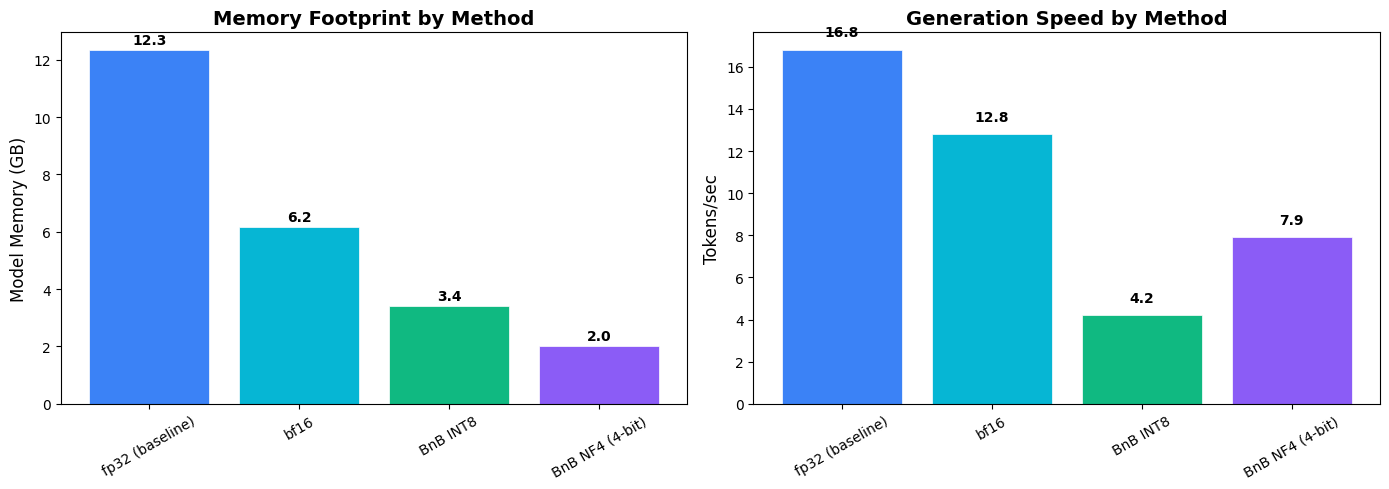

Plot saved to quantization_comparison.png


In [9]:
# Visual comparison
try:
    import matplotlib.pyplot as plt

    methods = list(results.keys())
    mem_vals = [results[m]["model_memory_gb"] for m in methods if isinstance(results[m]["model_memory_gb"], (int, float))]
    speed_vals = [results[m]["tokens_per_sec"] for m in methods if isinstance(results[m]["tokens_per_sec"], (int, float))]
    valid_methods_mem = [m for m in methods if isinstance(results[m]["model_memory_gb"], (int, float))]
    valid_methods_speed = [m for m in methods if isinstance(results[m]["tokens_per_sec"], (int, float))]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    colors = ["#3B82F6", "#06B6D4", "#10B981", "#8B5CF6", "#F59E0B"]

    # Memory comparison
    bars1 = axes[0].bar(valid_methods_mem, mem_vals, color=colors[:len(mem_vals)], edgecolor="white", linewidth=0.5)
    axes[0].set_ylabel("Model Memory (GB)", fontsize=12)
    axes[0].set_title("Memory Footprint by Method", fontsize=14, fontweight="bold")
    axes[0].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars1, mem_vals):
        axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.1,
                     f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

    # Speed comparison
    bars2 = axes[1].bar(valid_methods_speed, speed_vals, color=colors[:len(speed_vals)], edgecolor="white", linewidth=0.5)
    axes[1].set_ylabel("Tokens/sec", fontsize=12)
    axes[1].set_title("Generation Speed by Method", fontsize=14, fontweight="bold")
    axes[1].tick_params(axis='x', rotation=30)
    for bar, val in zip(bars2, speed_vals):
        axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
                     f'{val:.1f}', ha='center', va='bottom', fontweight='bold')

    plt.tight_layout()
    plt.savefig("quantization_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved to quantization_comparison.png")
except ImportError:
    print("matplotlib not available - see the table above for results")


## 10. Qualitative Comparison

Let's compare the actual generated responses side-by-side. Even at 4-bit, the outputs should be largely coherent - but watch for subtle quality differences.


In [10]:
print("="*70)
print("QUALITATIVE COMPARISON - Same prompt, different quantization")
print("="*70)

for name in results.keys():
    print(f"\n--- {name} ---")
    print(responses.get(name, "N/A")[:400])
    print()


QUALITATIVE COMPARISON - Same prompt, different quantization

--- fp32 (baseline) ---
Transformers are a type of neural network architecture that revolutionized natural language processing (NLP) by replacing the traditional recurrent neural networks (RNNs) with self-attention mechanisms. The core components of a transformer include self-attention, positional encoding, and the encoder-decoder architecture. Let's delve into each of these components:

### 1. Self-Attention Mechanism




--- bf16 ---
Transformers are a type of neural network architecture that revolutionized natural language processing (NLP) by offering a novel approach to modeling dependencies between words in text. They excel at tasks such as machine translation, text summarization, question answering, and many more. The core idea behind transformers is based on the concept of self-attention, which allows them to weigh the im


--- BnB INT8 ---
Transformers are a type of neural network that have revolutionized the field o

## 11. Understanding the Tradeoffs

### Memory Savings (approximate for Qwen2.5-3B):
| Method | Memory | vs fp32 | Calibration? |
|--------|--------|---------|-------------|
| fp32 | ~12 GB | 1× | - |
| bf16 | ~6 GB | 2× | - |
| BnB INT8 | ~3 GB | 4× | No |
| BnB NF4 | ~1.5 GB | 8× | No |
| GPTQ 4-bit | ~1.5 GB | 8× | Yes |
| AWQ 4-bit | ~1.5 GB | 8× | Yes |

### Quantization Time (one-time cost):
| Method | Quantization Time | Notes |
|--------|------------------|-------|
| bf16 | **Instant** | Just cast dtype on load |
| BnB INT8 | **Instant** | On-the-fly, no calibration |
| BnB NF4 | **Instant** | On-the-fly, no calibration |
| GPTQ 4-bit | **Minutes** | Calibration on ~128 C4 samples, layer-by-layer Hessian optimization |
| AWQ 4-bit | **Minutes** | Calibration to find salient weights via activation magnitudes |

### When to Use What:
| Scenario | Best Method | Why |
|----------|-------------|-----|
| Maximum accuracy (no constraints) | **fp32** | No information loss |
| Standard inference | **bf16** | 2× savings, negligible quality loss |
| Quick experiments / prototyping | **BnB NF4** | Zero setup, just `load_in_4bit=True` |
| QLoRA training | **BnB NF4** | Only method that supports backprop through quantized model |
| Production inference (best quality) | **AWQ** or **GPTQ** | Calibrated quantization preserves more accuracy |
| Production inference (fastest) | **GPTQ + Marlin/ExLlama kernels** | Optimized CUDA kernels for 4-bit |
| Serving many users | **GPTQ/AWQ** | Quantize once, save, deploy many times |

### Key Takeaways:
1. **fp32 → bf16** is a free lunch: 2× memory savings with virtually no quality loss
2. **BitsAndBytes** is unbeatable for convenience - zero calibration, works immediately
3. **GPTQ/AWQ** spend a few minutes calibrating but produce better quality at the same bit-width
4. All 4-bit methods give roughly **8× memory reduction vs fp32** - the difference is in accuracy and speed
5. You can **save** GPTQ/AWQ models and reload them instantly - the calibration cost is paid only once
6. From the quantization survey: RTN (naive rounding) collapses at 3-bit while GPTQ stays viable - calibration matters!
